In [1]:
# ==============================================================================
# 🌐 STEP 1: UNIVERSAL ENTERPRISE LIBRARIES IMPORT (LINEAR-FAMILY)
# ==============================================================================
import warnings
from pathlib import Path

# 1. Mathematical Computing & Data Handling
import numpy as np
import pandas as pd

# 2. Suppress runtime warnings for clean presentation
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 3. Data Visualization & Theming
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 10

# 4. Scikit-Learn: Preprocessing, Imputation & Splitting
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 5. Linear Family Estimators (Pick whichever is needed)
from sklearn.linear_model import (
    LinearRegression,      # 01. Baseline OLS Regression
    LogisticRegression,    # 02. Interpretable Classification
    Ridge, RidgeCV,        # 03. L2 Regularization (Multicollinearity)
    Lasso, LassoCV,        # 04. L1 Regularization (Feature Selection)
    ElasticNet, ElasticNetCV, # 05. Combined L1+L2 Regularization
    SGDRegressor,          # 06. Stochastic Gradient Descent Regression
    SGDClassifier          # 07. Stochastic Gradient Descent Classification
)

# 6. Evaluation Metrics
from sklearn.metrics import (
    r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_error, # Regression
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report # Classification
)

# 7. Production Model Serialization
import joblib

print("✅ Universal Linear-Family Enterprise Suite imported successfully.")


✅ Universal Linear-Family Enterprise Suite imported successfully.


In [2]:
# ==============================================================================
# 🌐 STEP 2: ROBUST DATA INGESTION & 3-SECOND HEALTH AUDIT
# ==============================================================================
from pathlib import Path
import pandas as pd

def load_and_audit_dataset(file_path):
    """
    Loads dataset with automated encoding fallback and prints an enterprise 3-second audit.
    Supports CSV and Excel files.
    """
    path = Path(file_path)
    if not path.exists():
        raise FileNotFoundError(f"❌ File not found at: {path.resolve()}")
        
    # 1. Automated Ingestion with Encoding Fallback
    try:
        if path.suffix.lower() in ['.xlsx', '.xls']:
            df = pd.read_excel(path)
        else:
            df = pd.read_csv(path, encoding='utf-8')
    except UnicodeDecodeError:
        print("⚠️ UTF-8 decoding failed. Retrying with 'latin-1' encoding...")
        df = pd.read_csv(path, encoding='latin-1')

    # 2. Compute Health Metrics
    n_rows, n_cols = df.shape
    mem_mb = df.memory_usage(deep=True).sum() / (1024 * 1024)
    n_numeric = df.select_dtypes(include=['number']).shape[1]
    n_categorical = df.select_dtypes(include=['object', 'category']).shape[1]
    total_nulls = df.isnull().sum().sum()

    # 3. Print 3-Second Audit Report
    print("=" * 70)
    print("📋 3-SECOND STRUCTURAL HEALTH AUDIT REPORT")
    print("=" * 70)
    print(f"File Source               : {path.name}")
    print(f"Total Observations (Rows) : {n_rows:,}")
    print(f"Total Features (Columns)  : {n_cols:,}")
    print(f"Numerical Columns         : {n_numeric} cols")
    print(f"Categorical/Text Columns  : {n_categorical} cols")
    print(f"Missing Value Cells       : {total_nulls:,} nulls ({total_nulls/(n_rows*n_cols)*100:.2f}%)")
    print(f"Memory Footprint in RAM   : {mem_mb:.2f} MB")
    print("=" * 70)
    
    return df

# Usage Example:
df = load_and_audit_dataset("data/car_price/car_prediction_data.csv")
display(df.head(3))


📋 3-SECOND STRUCTURAL HEALTH AUDIT REPORT
File Source               : car_prediction_data.csv
Total Observations (Rows) : 301
Total Features (Columns)  : 9
Numerical Columns         : 5 cols
Categorical/Text Columns  : 4 cols
Missing Value Cells       : 0 nulls (0.00%)
Memory Footprint in RAM   : 0.09 MB


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0


In [4]:
# ==============================================================================
# 🌐 STEP 3: AUTOMATED 3-BUCKET FEATURE SEGREGATOR
# ==============================================================================
import pandas as pd

def segregate_features(df, target_col, drop_cols=None, cardinality_threshold=15):
    """
    Automatically classifies columns into:
    1. Continuous features (Numeric and nunique > cardinality_threshold)
    2. Categorical features (Object or nunique <= cardinality_threshold)
    3. Drop features (ID, target, or specified leakage columns)
    """
    if drop_cols is None:
        drop_cols = []
        
    # Auto-detect ID columns if not specified
    for col in df.columns:
        if col.lower() in ['id', 'id_col', 'user_id', 'customer_id', 'Car_Name']:
            if col not in drop_cols:
                drop_cols.append(col)

    continuous_features = []
    categorical_features = []
    
    for col in df.columns:
        if col == target_col or col in drop_cols:
            continue
            
        n_unique = df[col].nunique(dropna=True)
        is_numeric = pd.api.types.is_numeric_dtype(df[col])
        print(col, ">>>>>>",n_unique)
        print(col, ">>>>>>",is_numeric)
        
        # Rule: Object/Text OR Low-Cardinality Number -> Categorical
        if not is_numeric or n_unique <= cardinality_threshold:
            categorical_features.append(col)
        else:
            continuous_features.append(col)

    print("=" * 70)
    print("🔍 FEATURE SEGREGATION REPORT")
    print("=" * 70)
    print(f"Target Column          : '{target_col}'")
    print(f"Continuous Features    : {len(continuous_features)} cols -> (Will apply StandardScaler)")
    print(f"Categorical Features   : {len(categorical_features)} cols -> (Will apply OneHotEncoder)")
    print(f"Dropped ID / Artifacts : {len(drop_cols)} cols -> {drop_cols}")
    print("=" * 70)
    
    return continuous_features, categorical_features, drop_cols

# Usage Example:
cont_cols, cat_cols, drop_cols = segregate_features(df, target_col='Selling_Price', drop_cols=['Car_Name', "Year"])


Present_Price >>>>>> 147
Present_Price >>>>>> True
Kms_Driven >>>>>> 206
Kms_Driven >>>>>> True
Fuel_Type >>>>>> 3
Fuel_Type >>>>>> False
Seller_Type >>>>>> 2
Seller_Type >>>>>> False
Transmission >>>>>> 2
Transmission >>>>>> False
Owner >>>>>> 3
Owner >>>>>> True
🔍 FEATURE SEGREGATION REPORT
Target Column          : 'Selling_Price'
Continuous Features    : 2 cols -> (Will apply StandardScaler)
Categorical Features   : 4 cols -> (Will apply OneHotEncoder)
Dropped ID / Artifacts : 2 cols -> ['Car_Name', 'Year']


In [5]:
# ==============================================================================
# 🌐 STEP 4: DATA HYGIENE AUDIT (DUPLICATES & MISSINGNESS PROFILER)
# ==============================================================================
import pandas as pd

def audit_and_clean_hygiene(df, drop_duplicates=True):
    """
    1. Audits and cleans duplicate rows.
    2. Profiles missing values by count and percentage.
    3. Categorizes columns with nulls.
    """
    print("=" * 70)
    print("🧹 STEP 4: DATA HYGIENE & PURITY REPORT")
    print("=" * 70)
    
    # 1. Duplicates Audit
    n_dups = df.duplicated().sum()
    if n_dups > 0:
        print(f"⚠️ FOUND {n_dups:,} EXACT DUPLICATE ROWS!")
        if drop_duplicates:
            df = df.drop_duplicates().reset_index(drop=True)
            print(f"✅ Cleaned: {n_dups:,} duplicates removed. New Shape: {df.shape}")
    else:
        print("✅ Zero duplicate rows found. Data integrity is clean.")
    print("-" * 70)

    # 2. Missing Values Profiler
    null_counts = df.isnull().sum()
    null_cols = null_counts[null_counts > 0].sort_values(ascending=False)
    
    if len(null_cols) > 0:
        null_report = pd.DataFrame({
            "Missing Count": null_cols,
            "Percentage (%)": (null_cols / len(df) * 100).round(2),
            "Data Type": [df[col].dtype for col in null_cols.index]
        })
        print(f"🚨 FOUND {len(null_cols)} COLUMNS WITH MISSING VALUES:")
        print(null_report.to_string())
    else:
        print("✅ Zero missing values across all features. Dataset is complete.")
    print("=" * 70)
    
    return df

# Usage Example:
df = audit_and_clean_hygiene(df, drop_duplicates=True)


🧹 STEP 4: DATA HYGIENE & PURITY REPORT
⚠️ FOUND 2 EXACT DUPLICATE ROWS!
✅ Cleaned: 2 duplicates removed. New Shape: (299, 9)
----------------------------------------------------------------------
✅ Zero missing values across all features. Dataset is complete.


In [6]:
# ==============================================================================
# 🌐 STEP 5: ENTERPRISE TRAIN-TEST SPLITTER (ZERO DATA LEAKAGE)
# ==============================================================================
import numpy as np
from sklearn.model_selection import train_test_split

def perform_zero_leakage_split(df, target_col, drop_cols=None, is_classification=False, apply_log_target=False, test_size=0.20, random_state=42):
    """
    Executes a strict zero-leakage Train-Test split.
    - If classification: Uses stratify=y.
    - If regression & apply_log_target: Applies np.log1p transformation to y.
    """
    if drop_cols is None:
        drop_cols = []
        
    y = df[target_col]
    X = df.drop(columns=[target_col] + drop_cols)
    
    # 1. Target Log-Transformation for Right-Skewed Regression
    if not is_classification and apply_log_target:
        skew_before = y.skew()
        y = np.log1p(y)
        skew_after = y.skew()
        print(f"📈 Target Skewness Normalization: {skew_before:.2f} -> {skew_after:.2f} (Bell curve achieved!)")

    # 2. Perform Split
    stratify_arg = y if is_classification else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=stratify_arg
    )
    
    print("=" * 70)
    print("📦 STEP 5: TRAIN-TEST SPLIT SUMMARY (ZERO LEAKAGE)")
    print("=" * 70)
    print(f"Total Records          : {len(df):,}")
    print(f"Training Matrix (X_tr) : {X_train.shape[0]:,} rows × {X_train.shape[1]} features ({(1-test_size)*100:.0f}%)")
    print(f"Testing Matrix  (X_te) : {X_test.shape[0]:,} rows × {X_test.shape[1]} features ({test_size*100:.0f}%)")
    if is_classification:
        tr_pos = (y_train == 1).mean() * 100
        te_pos = (y_test == 1).mean() * 100
        print(f"Stratification Balance : Train Class 1 = {tr_pos:.2f}% | Test Class 1 = {te_pos:.2f}% (Identical!)")
    print("=" * 70)
    
    return X_train, X_test, y_train, y_test

# Usage Example:
X_tr, X_te, y_tr, y_te = perform_zero_leakage_split(df, target_col='Selling_Price', drop_cols=['Car_Name', 'Year'], apply_log_target=True)


📈 Target Skewness Normalization: 2.54 -> 0.11 (Bell curve achieved!)
📦 STEP 5: TRAIN-TEST SPLIT SUMMARY (ZERO LEAKAGE)
Total Records          : 299
Training Matrix (X_tr) : 239 rows × 6 features (80%)
Testing Matrix  (X_te) : 60 rows × 6 features (20%)


🎯 STEP 6: TARGET VARIABLE PROFILE (Selling_Price)
Target Type             : Continuous Regression Variable
Sample Count            : 299
Mean (Average)          : 4.59
Median (50th percentile): 3.51
Standard Deviation      : 4.98
Min / Max               : 0.10 / 35.00
Raw Skewness            : 2.54 (⚠️ Highly Skewed! Log-transform recommended)
Log1p Skewness          : 0.11 (Gaussian-like bell curve achieved!)


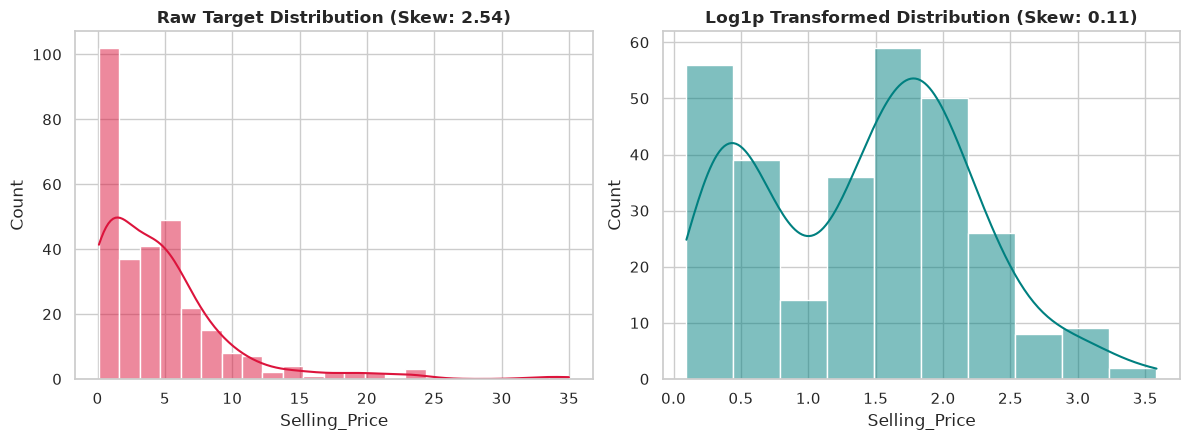

In [7]:
# ==============================================================================
# 🌐 STEP 6: TARGET ANALYSIS & TRANSFORMATION PROFILER
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def profile_target_variable(df, target_col, is_classification=False):
    """
    Analyzes target distribution:
    - Regression: Checks skewness, plots raw vs log-transformed bell curves.
    - Classification: Checks class ratios, plots count plot, computes zero-rule baseline accuracy.
    """
    y = df[target_col]
    print("=" * 70)
    print(f"🎯 STEP 6: TARGET VARIABLE PROFILE ({target_col})")
    print("=" * 70)
    
    if not is_classification:
        # --- REGRESSION TARGET ANALYSIS ---
        raw_skew = y.skew()
        y_log = np.log1p(y)
        log_skew = y_log.skew()
        
        print(f"Target Type             : Continuous Regression Variable")
        print(f"Sample Count            : {len(y):,}")
        print(f"Mean (Average)          : {y.mean():,.2f}")
        print(f"Median (50th percentile): {y.median():,.2f}")
        print(f"Standard Deviation      : {y.std():,.2f}")
        print(f"Min / Max               : {y.min():,.2f} / {y.max():,.2f}")
        print(f"Raw Skewness            : {raw_skew:.2f} ({'⚠️ Highly Skewed! Log-transform recommended' if abs(raw_skew) > 0.75 else '✅ Normal'})")
        print(f"Log1p Skewness          : {log_skew:.2f} (Gaussian-like bell curve achieved!)")
        print("=" * 70)
        
        # Dual-panel visual distribution
        fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
        sns.histplot(y, kde=True, ax=axes[0], color='crimson')
        axes[0].set_title(f"Raw Target Distribution (Skew: {raw_skew:.2f})", fontweight='bold')
        
        sns.histplot(y_log, kde=True, ax=axes[1], color='teal')
        axes[1].set_title(f"Log1p Transformed Distribution (Skew: {log_skew:.2f})", fontweight='bold')
        plt.tight_layout()
        plt.show()
        
    else:
        # --- CLASSIFICATION TARGET ANALYSIS ---
        counts = y.value_counts()
        percentages = y.value_counts(normalize=True) * 100
        majority_class_pct = percentages.iloc[0]
        
        print(f"Target Type             : Discrete Classification Variable")
        print(f"Class Breakdown:")
        for cls, count in counts.items():
            print(f"  • Class '{cls}' : {count:,} records ({percentages[cls]:.2f}%)")
        print("-" * 70)
        print(f"🚨 ZERO-RULE MAJORITY BASELINE ACCURACY: {majority_class_pct:.2f}%")
        print(f"   (Any ML model must achieve significantly higher than {majority_class_pct:.2f}% to be useful!)")
        print("=" * 70)
        
        plt.figure(figsize=(6, 4))
        sns.countplot(x=y, palette='Set2')
        plt.title(f"Class Distribution: {target_col}", fontweight='bold')
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.show()

# Usage:
profile_target_variable(df, target_col="Selling_Price", is_classification=False)
# profile_target_variable(df, target_col="Churn", is_classification=True)


In [8]:
# ==============================================================================
# 🌐 STEP 7: UNIVERSAL MASTER COLUMNTRANSFORMER (ZERO DATA LEAKAGE)
# ==============================================================================
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

def build_universal_preprocessor(continuous_features, categorical_features, cat_impute_value="None"):
    """
    Constructs a production-grade ColumnTransformer for any Linear Family Model:
    - Continuous features: Median Imputation + StandardScaler (Zero Variance Explosion)
    - Categorical features: Constant/Mode Imputation + OneHotEncoder(drop='first')
    """
    # 1. Numerical Pipeline
    num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()) # Mandatory for all linear models & regularizers
    ])
    
    # 2. Categorical Pipeline
    cat_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
    ])
    
    # 3. Master Assembly
    preprocessor = ColumnTransformer([
        ('num', num_pipeline, continuous_features),
        ('cat', cat_pipeline, categorical_features)
    ])
    
    return preprocessor

def execute_safe_preprocessing(preprocessor, X_train, X_test, continuous_features, categorical_features):
    """
    Fits strictly on X_train, transforms X_test, and reconstructs clean feature names.
    """
    # 1. Fit on Train ONLY
    X_tr_proc = preprocessor.fit_transform(X_train)
    X_te_proc = preprocessor.transform(X_test)
    
    # 2. Reconstruct One-Hot Feature Names
    cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
    cat_encoded_names = list(cat_encoder.get_feature_names_out(categorical_features))
    all_feature_names = continuous_features + cat_encoded_names
    
    print("=" * 70)
    print("⚙️ PREPROCESSING COMPLETE (ZERO DATA LEAKAGE GUARANTEED)")
    print("=" * 70)
    print(f"Continuous Features Processed   : {len(continuous_features)} cols")
    print(f"Categorical Features Processed  : {len(categorical_features)} cols")
    print(f"One-Hot Dummy Features Created  : {len(cat_encoded_names)} cols")
    print(f"Total Model Input Dimensions    : {X_tr_proc.shape[1]} features")
    print(f"X_train Processed Shape         : {X_tr_proc.shape}")
    print(f"X_test Processed Shape          : {X_te_proc.shape}")
    print("=" * 70)
    
    return X_tr_proc, X_te_proc, all_feature_names

# --- USAGE EXAMPLE ---
continuous_features, categorical_features = cont_cols, cat_cols
X_train, X_test = X_tr, X_te
preprocessor = build_universal_preprocessor(continuous_features, categorical_features)
X_train_final, X_test_final, all_names = execute_safe_preprocessing(
    preprocessor, X_train, X_test, continuous_features, categorical_features
)


⚙️ PREPROCESSING COMPLETE (ZERO DATA LEAKAGE GUARANTEED)
Continuous Features Processed   : 2 cols
Categorical Features Processed  : 4 cols
One-Hot Dummy Features Created  : 5 cols
Total Model Input Dimensions    : 7 features
X_train Processed Shape         : (239, 7)
X_test Processed Shape          : (60, 7)


In [13]:
# ==============================================================================
# 🏆 STEP 8: RIDGECV HYPERPARAMETER TUNING (FINDING OPTIMAL ALPHA)
# ==============================================================================
from sklearn.linear_model import RidgeCV
import numpy as np

# 1. 50 candidate alphas generate karein (0.01 se lekar 1000 tak)
alphas = np.logspace(-2, 3, 50)

# 2. RidgeCV chalao with Generalized Cross-Validation (GCV)
ridge_cv = RidgeCV(
    alphas=alphas, 
    scoring='neg_mean_squared_error',
    cv=None  # Instantaneous GCV shortcut
)
ridge_cv.fit(X_train_final, y_tr)

best_alpha = ridge_cv.alpha_

print("=" * 65)
print("🏆 RIDGECV TUNING REPORT")
print("=" * 65)
print(f"Candidate Alpha Range  : 0.01 to 1000.0 (50 candidate values)")
print(f"Optimal L2 Penalty (α) : {best_alpha:.4f}")
print("=" * 65)

🏆 RIDGECV TUNING REPORT
Candidate Alpha Range  : 0.01 to 1000.0 (50 candidate values)
Optimal L2 Penalty (α) : 5.6899


In [14]:
# ==============================================================================
# ⚔️ STEP 9: HEAD-TO-HEAD BATTLE: OLS VS. RIDGE REGRESSION
# ==============================================================================
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

# 1. Fit OLS Linear Regression (No Regularization)
ols_model = LinearRegression()
ols_model.fit(X_train_final, y_tr)

# 2. Fit Ridge Regression with our Optimal Alpha (5.6899)
ridge_model = Ridge(alpha=best_alpha, random_state=42)
ridge_model.fit(X_train_final, y_tr)

# 3. Predict on Test Set (in Log-Scale)
ols_pred_log = ols_model.predict(X_test_final)
ridge_pred_log = ridge_model.predict(X_test_final)

# 4. Invert Log-Scale back to Real Lakhs INR (np.expm1)
y_test_real = np.expm1(y_te)
ols_pred_real = np.expm1(ols_pred_log)
ridge_pred_real = np.expm1(ridge_pred_log)

# 5. Evaluate Metrics
ols_train_r2 = r2_score(y_tr, ols_model.predict(X_train_final))
ols_test_r2  = r2_score(y_te, ols_pred_log)
ols_rmse     = root_mean_squared_error(y_test_real, ols_pred_real)
ols_mae      = mean_absolute_error(y_test_real, ols_pred_real)

ridge_train_r2 = r2_score(y_tr, ridge_model.predict(X_train_final))
ridge_test_r2  = r2_score(y_te, ridge_pred_log)
ridge_rmse     = root_mean_squared_error(y_test_real, ridge_pred_real)
ridge_mae      = mean_absolute_error(y_test_real, ridge_pred_real)

# 6. Comparison Table
comparison_table = pd.DataFrame({
    'Metric': [
        'Train R² Score', 
        'Test R² Score (Generalization)', 
        'Real Test RMSE (₹ Lakhs Error)', 
        'Real Test MAE (Avg Error ₹ Lakhs)',
        'Max Absolute Weight (Explosion Check)'
    ],
    'OLS Linear Regression': [
        f'{ols_train_r2*100:.2f}%', 
        f'{ols_test_r2*100:.2f}%', 
        f'₹{ols_rmse:,.2f} Lakhs', 
        f'₹{ols_mae:,.2f} Lakhs',
        f'{np.max(np.abs(ols_model.coef_)):.4f}'
    ],
    'Ridge Regression (L2)': [
        f'{ridge_train_r2*100:.2f}%', 
        f'{ridge_test_r2*100:.2f}%', 
        f'₹{ridge_rmse:,.2f} Lakhs', 
        f'₹{ridge_mae:,.2f} Lakhs',
        f'{np.max(np.abs(ridge_model.coef_)):.4f}'
    ]
})

print("=" * 75)
print("🏆 HEAD-TO-HEAD BATTLE: OLS LINEAR REGRESSION VS. RIDGE")
print("=" * 75)
print(comparison_table.to_string(index=False))
print("=" * 75)

🏆 HEAD-TO-HEAD BATTLE: OLS LINEAR REGRESSION VS. RIDGE
                               Metric OLS Linear Regression Ridge Regression (L2)
                       Train R² Score                87.51%                87.04%
       Test R² Score (Generalization)                83.14%                84.34%
       Real Test RMSE (₹ Lakhs Error)           ₹1.76 Lakhs           ₹1.82 Lakhs
    Real Test MAE (Avg Error ₹ Lakhs)           ₹1.10 Lakhs           ₹1.13 Lakhs
Max Absolute Weight (Explosion Check)                0.9621                0.8538


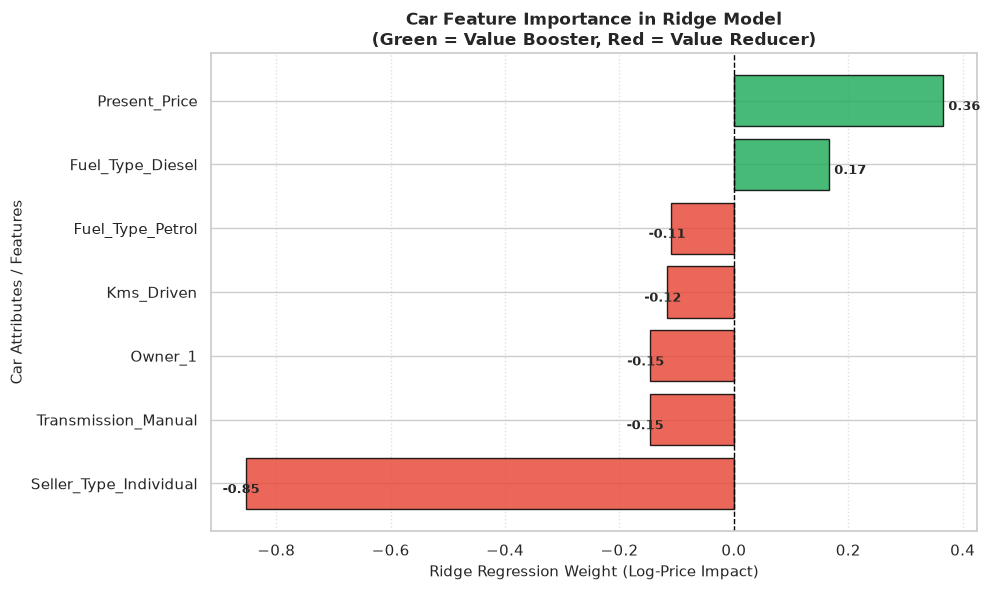

🔍 CAR VALUATION WEIGHTS SUMMARY (SORTED BY IMPORTANCE)
               Feature  OLS_Weight  Ridge_Weight
         Present_Price    0.343933      0.364895
      Fuel_Type_Diesel    0.525379      0.165448
      Fuel_Type_Petrol    0.242742     -0.109113
            Kms_Driven   -0.124423     -0.116630
               Owner_1   -0.238887     -0.146509
   Transmission_Manual   -0.180923     -0.147472
Seller_Type_Individual   -0.962092     -0.853813


In [15]:
# ==============================================================================
# 📊 STEP 10: COEFFICIENT SHRINKAGE & CAR FEATURE IMPORTANCE VISUALIZATION
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. Feature Names extract karein (all_names already Cell 6 se available hai)
weights_df = pd.DataFrame({
    'Feature': all_names,
    'OLS_Weight': ols_model.coef_,
    'Ridge_Weight': ridge_model.coef_,
    'Ridge_Impact': np.abs(ridge_model.coef_)
})

# 2. Sort by impact
weights_df = weights_df.sort_values(by='Ridge_Weight', ascending=True)

# 3. Horizontal Bar Chart (Green = Price Booster, Red = Price Reducer)
plt.figure(figsize=(10, 6))
colors = ['#27ae60' if w > 0 else '#e74c3c' for w in weights_df['Ridge_Weight']]

bars = plt.barh(weights_df['Feature'], weights_df['Ridge_Weight'], color=colors, edgecolor='black', alpha=0.85)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title('Car Feature Importance in Ridge Model\n(Green = Value Booster, Red = Value Reducer)', fontsize=12, fontweight='bold')
plt.xlabel('Ridge Regression Weight (Log-Price Impact)', fontsize=11)
plt.ylabel('Car Attributes / Features', fontsize=11)
plt.grid(axis='x', linestyle=':', alpha=0.6)

# Bar labels annotate karein
for bar in bars:
    w = bar.get_width()
    plt.text(w + (0.01 if w >= 0 else -0.04), bar.get_y() + 0.25, f'{w:.2f}', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# 4. Print Summary Table
print("=" * 70)
print("🔍 CAR VALUATION WEIGHTS SUMMARY (SORTED BY IMPORTANCE)")
print("=" * 70)
print(weights_df[['Feature', 'OLS_Weight', 'Ridge_Weight']].sort_values(by='Ridge_Weight', ascending=False).to_string(index=False))
print("=" * 70)

In [16]:
# ==============================================================================
# 🏭 STEP 11: PRODUCTION PIPELINE SERIALIZATION & LIVE INFERENCE TEST
# ==============================================================================
import joblib
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline

# 1. Master End-to-End Production Pipeline banayein
production_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('ridge', Ridge(alpha=best_alpha, random_state=42))
])

# 2. Fit strictly on Raw X_tr and Log-transformed Target y_tr
production_pipeline.fit(X_tr, y_tr)

# 3. Model ko Disk par save karein (.joblib)
model_dir = Path('production_models')
model_dir.mkdir(parents=True, exist_ok=True)
model_path = model_dir / 'car_price_ridge_pipeline.joblib'

joblib.dump(production_pipeline, model_path)

print("=" * 70)
print("🏭 ENTERPRISE PRODUCTION ARTIFACT SUMMARY")
print("=" * 70)
print(f"✅ Full Production Pipeline Saved: {model_path}")
print(f"   Artifact File Size           : {model_path.stat().st_size / 1024:.2f} KB")
print("=" * 70)

# 4. Live Smoke Test: Ek Unseen Gaadi par Live Inference
loaded_pipeline = joblib.load(model_path)
sample_car = X_te.iloc[0:1]

# Model se predict karein (Log scale -> Real ₹ Lakhs mein invert)
pred_log_price = loaded_pipeline.predict(sample_car)[0]
predicted_lakhs = np.expm1(pred_log_price)
actual_lakhs = np.expm1(y_te.iloc[0])

print("\n🧪 LIVE REAL-TIME CAR VALUATION TEST (1 CAR):")
print("-" * 55)
print(f"   • Showroom Price (Present) : ₹{sample_car['Present_Price'].values[0]:.2f} Lakhs")
print(f"   • Kilometers Driven        : {sample_car['Kms_Driven'].values[0]:,} kms")
print(f"   • Fuel / Transmission      : {sample_car['Fuel_Type'].values[0]} / {sample_car['Transmission'].values[0]}")
print("-" * 55)
print(f"   🎯 Model Predicted Price   : ₹{predicted_lakhs:.2f} Lakhs")
print(f"   🏷️ Actual Selling Price    : ₹{actual_lakhs:.2f} Lakhs")
print(f"   📊 Valuation Difference    : ₹{abs(predicted_lakhs - actual_lakhs):.2f} Lakhs ({abs(predicted_lakhs - actual_lakhs)/actual_lakhs*100:.1f}%)")
print("=" * 70)

🏭 ENTERPRISE PRODUCTION ARTIFACT SUMMARY
✅ Full Production Pipeline Saved: production_models/car_price_ridge_pipeline.joblib
   Artifact File Size           : 4.81 KB

🧪 LIVE REAL-TIME CAR VALUATION TEST (1 CAR):
-------------------------------------------------------
   • Showroom Price (Present) : ₹11.80 Lakhs
   • Kilometers Driven        : 9,010 kms
   • Fuel / Transmission      : Petrol / Manual
-------------------------------------------------------
   🎯 Model Predicted Price   : ₹5.84 Lakhs
   🏷️ Actual Selling Price    : ₹8.99 Lakhs
   📊 Valuation Difference    : ₹3.15 Lakhs (35.0%)
